# Two-Spin Quantum Dot Tutorial

This notebook extends the single-spin tutorial to a two-spin quantum dot. The main goal is to understand how the coupling between two localized spins changes the energy spectrum and gives rise to additional ESR transitions.

In a two-spin system, the quantum dot has more internal states than in the single-spin case. In particular:

- each site can carry a spin-1/2 moment
- exchange coupling can create singlet-triplet splitting and mixed states
- several resonant frequencies may appear, corresponding to different transitions between many-body eigenstates
- the ESR signal can contain harmonics and subharmonic features that are absent in the single-spin case

We will build the model, inspect the eigenstates and transition energies, compute the ESR spectrum, and investigate how the signal changes when the two spins are made inequivalent by anisotropy or field differences.

In [1]:
import numpy as np 
import matplotlib.pyplot as plt

from time import time

import sys 
sys.path.append('..')

import PyESRSTM
from PyESRSTM import units

## Spin System

We now define a quantum dot with two spin-1/2 sites. Each site has a local magnetic field and a gyromagnetic factor, and the two spins are coupled by an exchange interaction.

The relevant parameters are:

- `eps`: the single-particle energy of each site
- `U`: the Coulomb repulsion between electrons
- `Bext`: the external magnetic field on each spin site
- `Jexch`: the exchange coupling between the two spins

The `QD` object builds the full many-body Hamiltonian for the two-spin system and returns the eigenstates, energy splittings, and many-body transition frequencies. This is the natural extension of the single-spin tutorial.

In [2]:
eps = -30
U = 100
Bext = np.array([0.1,  0.,  0.3])
Jexch = np.array([3.,3.,3.])
dot = PyESRSTM.QD(-30, 100, np.array([0.5, .5]), np.array([Bext, Bext]), 
        np.array([[2.0, 2.0, 2.0],[2.0, 2.0, 2.0]]),Jexch=[[Jexch,1,0], ])

Hermiticity check passed!
Hermiticity check passed!


In [3]:
print(dot)

idx 	Occup 	Energy [meV] 	Spin central 	Spin total
				 x,  y,  z 	 x,  y,  z
0	1 	-30.033507190 	-0.2 -0.0 -0.5 	-0.3 -0.0 -0.9
1	1 	-30.009305252 	0.0 0.0 0.0 	0.0 0.0 0.0
2	1 	-29.996898249 	0.0 0.0 -0.0 	0.0 0.0 -0.0
3	1 	-29.960289308 	0.2 0.0 0.5 	0.3 0.0 0.9
4	0 	-0.018304470 	0.0 0.0 0.0 	-0.2 -0.0 -0.5
5	0 	0.018304470 	0.0 0.0 0.0 	0.2 0.0 0.5
6	2 	39.981695530 	0.0 0.0 0.0 	-0.2 -0.0 -0.5
7	2 	40.018304470 	0.0 0.0 0.0 	0.2 0.0 0.5


In [4]:
print('Number of spins:',dot.Nspin)
print('Number of states:',dot.Nstate)
print('Occupancy:',dot.Occupancy)
print('Energies [meV]:', np.round(dot.Energies*units.Hartree,3))
print('Theta [deg]: ', np.round(dot.theta/np.pi*180, 3))
print()

print('Spins states')
print('state, spin site,  <Sx>, <Sy>,  <Sz>')
print(np.round(dot.CalcAllSpin(),3))

Number of spins: 2
Number of states: 8
Occupancy: [1 1 1 1 0 0 2 2]
Energies [meV]: [-3.0034e+01 -3.0009e+01 -2.9997e+01 -2.9960e+01 -1.8000e-02  1.8000e-02
  3.9982e+01  4.0018e+01]
Theta [deg]:  18.435

Spins states
state, spin site,  <Sx>, <Sy>,  <Sz>
[[[ 1.     1.    -0.158 -0.    -0.474]
  [ 1.     2.    -0.158 -0.    -0.474]]

 [[ 2.     1.     0.     0.     0.   ]
  [ 2.     2.     0.     0.    -0.   ]]

 [[ 3.     1.     0.     0.    -0.   ]
  [ 3.     2.     0.     0.    -0.   ]]

 [[ 4.     1.     0.158  0.     0.474]
  [ 4.     2.     0.158  0.     0.474]]

 [[ 5.     1.     0.     0.     0.   ]
  [ 5.     2.    -0.158 -0.    -0.474]]

 [[ 6.     1.     0.     0.     0.   ]
  [ 6.     2.     0.158  0.     0.474]]

 [[ 7.     1.     0.     0.     0.   ]
  [ 7.     2.    -0.158 -0.    -0.474]]

 [[ 8.     1.     0.     0.     0.   ]
  [ 8.     2.     0.158  0.     0.474]]]


We should now have several resonance frequencies, corresponding to transitions between different many-body states of the doubly occupied and singly occupied configurations. These frequencies are obtained from the energy differences stored in `dot.Delta`.

The key insight is that a two-spin system does not just produce one resonance. Instead, several transitions can appear, and the ESR signal may include multiple peaks and subharmonics due to the internal spin structure and exchange coupling.

In [5]:
Del = dot.Delta[:4,:4]*units.Hartree/units.GHz
resonant = np.unique(np.abs(Del))[1:]

print('Delta:')
print(np.round(Del,3))

print('Freqeuncies')
print(f'f1: |g> -> |->: {resonant[0]:.2f} GHz')
print(f'f2: |-> -> |+>: {resonant[1]:.2f} GHz')
print(f'f3: |+> -> |e>: {resonant[2]:.2f} GHz')
print(f'f4: |g> -> |+>: {resonant[3]:.2f} GHz')
print(f'f5: |-> -> |e>: {resonant[4]:.2f} GHz')
print(f'f6: |g> -> |e>: {resonant[5]:.2f} GHz')

Delta:
[[  0.      5.852   8.852  17.704]
 [ -5.852   0.      3.     11.852]
 [ -8.852  -3.      0.      8.852]
 [-17.704 -11.852  -8.852   0.   ]]
Freqeuncies
f1: |g> -> |->: 3.00 GHz
f2: |-> -> |+>: 5.85 GHz
f3: |+> -> |e>: 8.85 GHz
f4: |g> -> |+>: 8.85 GHz
f5: |-> -> |e>: 11.85 GHz
f6: |g> -> |e>: 17.70 GHz


### ESR Signal

To compute the ESR response, we define the two electrodes and scan the driving frequency over a broad range. As in the single-spin case, the ESR signal is obtained by solving the master equation for each frequency and extracting the current response.

In a two-spin system, you often find multiple resonances corresponding to different transition energies. We can also examine whether the observed peaks appear at the fundamental transitions or at smaller fractions of the transition energy, such as $f/2$, $f/3$, etc. These harmonic features can arise from higher-order Fourier components and nontrivial many-body dynamics.

In [6]:
Right = PyESRSTM.Electrode(0,   0, 0.,     5e-3,       1e-1,         4.5,  Nint=1e4, Cutoff=1000)
Left = PyESRSTM.Electrode(-25, 4, 0.5, 1.25e-3, 1e-1, 4.5, Nint=1e4, Cutoff=1000)
frequencies = np.linspace(0.5, 20, 2000)

To separate the fundamental transitions from higher-order harmonics and subharmonic features, we compute the ESR signal with increasing numbers of Fourier components. This is important because in a multi-level system, a single transition can generate response at several harmonic orders, depending on the coupling structure and the underlying Floquet dynamics.

In [7]:
I0 = PyESRSTM.ESR.ESR(Left, Right, dot, frequencies)[:,0]
I1 = PyESRSTM.ESR.ESR(Left, Right, dot, frequencies, NFL=1)[:,1]
I2 = PyESRSTM.ESR.ESR(Left, Right, dot, frequencies, NFL=2)[:,2]
I3 = PyESRSTM.ESR.ESR(Left, Right, dot, frequencies, NFL=3)[:,3]
I4 = PyESRSTM.ESR.ESR(Left, Right, dot, frequencies, NFL=4)[:,4]

In [8]:

I1n = I1 - I1[0]
I2n = I2 - I1   
I4n = I4 - I3   
I3n = I3 - I2   

I1n /= np.max(I1n) - np.min(I1n)
I2n /= np.max(I2n) - np.min(I2n)
I3n /= np.max(I3n) - np.min(I3n)
I4n /= np.max(I4n) - np.min(I4n)

/home/matyas/micromamba/envs/pyscf-env/lib/python3.9/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/matyas/micromamba/envs/pyscf-env/lib/python3.9/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


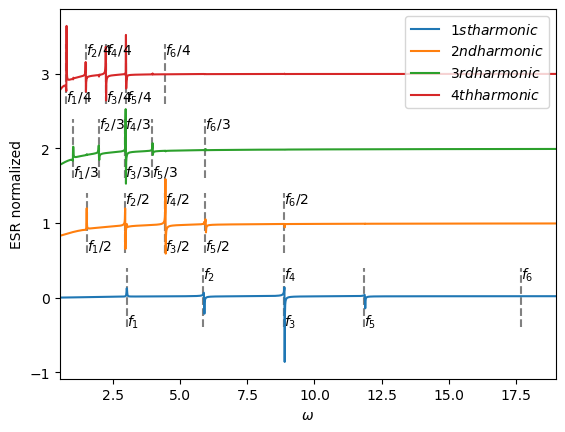

In [9]:
shift = 1

plt.vlines(resonant  , -.4+0*shift, .4+0*shift, 'gray', '--')
plt.vlines(resonant/2, -.4+1*shift, .4+1*shift, 'gray', '--')
plt.vlines(resonant/3, -.4+2*shift, .4+2*shift, 'gray', '--')
plt.vlines(resonant/4, -.4+3*shift, .4+3*shift, 'gray', '--')

plt.plot(frequencies, I1n+0*shift, label=r'$1st harmonic$')
plt.plot(frequencies, I2n+1*shift, label=r'$2nd harmonic$')
plt.plot(frequencies, I3n+2*shift, label=r'$3rd harmonic$')
plt.plot(frequencies, I4n+3*shift, label=r'$4th harmonic$')

plt.text(resonant[0],0*shift-.2,r'$f_1$', ha='left', va='top')
plt.text(resonant[1],0*shift+.2,r'$f_2$', ha='left', va='bottom')
plt.text(resonant[2],0*shift-.2,r'$f_3$', ha='left', va='top')
plt.text(resonant[3],0*shift+.2,r'$f_4$', ha='left', va='bottom')
plt.text(resonant[4],0*shift-.2,r'$f_5$', ha='left', va='top')
plt.text(resonant[5],0*shift+.2,r'$f_6$', ha='left', va='bottom')

plt.text(resonant[0]/2,1*shift-.2,r'$f_1/2$', ha='left', va='top')
plt.text(resonant[1]/2,1*shift+.2,r'$f_2/2$', ha='left', va='bottom')
plt.text(resonant[2]/2,1*shift-.2,r'$f_3/2$', ha='left', va='top')
plt.text(resonant[3]/2,1*shift+.2,r'$f_4/2$', ha='left', va='bottom')
plt.text(resonant[4]/2,1*shift-.2,r'$f_5/2$', ha='left', va='top')
plt.text(resonant[5]/2,1*shift+.2,r'$f_6/2$',ha='left', va='bottom')

plt.text(resonant[0]/3,2*shift-.2,r'$f_1/3$', ha='left', va='top')
plt.text(resonant[1]/3,2*shift+.2,r'$f_2/3$', ha='left', va='bottom')
plt.text(resonant[2]/3,2*shift-.2,r'$f_3/3$', ha='left', va='top')
plt.text(resonant[3]/3,2*shift+.2,r'$f_4/3$', ha='left', va='bottom')
plt.text(resonant[4]/3,2*shift-.2,r'$f_5/3$', ha='left', va='top')
plt.text(resonant[5]/3,2*shift+.2,r'$f_6/3$', ha='left', va='bottom')

plt.text(resonant[0]/4,3*shift-.2,r'$f_1/4$', ha='left', va='top')
plt.text(resonant[1]/4,3*shift+.2,r'$f_2/4$', ha='left', va='bottom')
plt.text(resonant[2]/4,3*shift-.2,r'$f_3/4$', ha='left', va='top')
plt.text(resonant[3]/4,3*shift+.2,r'$f_4/4$', ha='left', va='bottom')
plt.text(resonant[4]/4,3*shift-.2,r'$f_5/4$', ha='left', va='top')
plt.text(resonant[5]/4,3*shift+.2,r'$f_6/4$', ha='left', va='bottom')

plt.xlim(0.5,19)

plt.xlabel(r'$\omega$')
plt.ylabel(r'ESR normalized')
plt.legend()
plt.show()

Note that we do not see a signal at $f_6$. Physically, this means the transition between the ground state and the highest-energy many-body configuration is not strongly coupled to the ESR drive in this symmetric setup.

This happens because the two sites have the same spin and same local environment, so the corresponding states are not strongly distinguishable by the driving field. In practice, this situation is often broken by one of the following:

- a different magnetic field on the two sites
- anisotropic exchange coupling
- an inhomogeneous local environment near the tip

These effects lift the degeneracy or mix the many-body states in a way that makes the transition visible in the ESR spectrum.

In [10]:
Jexch_anisopt = np.array([3.,0.,0.])
Bext_2 = np.array([0.3,  0.,  0.1])
dot_two_field = PyESRSTM.QD(-30, 100, np.array([0.5, .5]), np.array([Bext, Bext_2]), 
        np.array([[2.0, 2.0, 2.0],[2.0, 2.0, 2.0]]),Jexch=[[Jexch,1,0], ])
dot_anisop = PyESRSTM.QD(-30, 100, np.array([0.5, .5]), np.array([Bext, Bext]), 
        np.array([[2.0, 2.0, 2.0],[2.0, 2.0, 2.0]]),Jexch=[[Jexch_anisopt,1,0], ])

resonant_two_field = np.unique(np.abs(dot_two_field.Delta[:4,:4]))[1:]*units.Hartree/units.GHz
resonant_anisop = np.unique(np.abs(dot_anisop.Delta[:4,:4]))[1:]*units.Hartree/units.GHz

Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!


In [11]:
I1_two_field = PyESRSTM.ESR.ESR(Left, Right, dot_two_field, frequencies, NFL=1)[:,1]
I1_anisop = PyESRSTM.ESR.ESR(Left, Right, dot_anisop, frequencies, NFL=1)[:,1]

In [12]:
I1_two_field_n = I1_two_field - I1_two_field[0]
I1_anisop_n = I1_anisop - I1_anisop[0]

I1_two_field_n /= np.max(I1_two_field_n) - np.min(I1_two_field_n)
I1_anisop_n /= np.max(I1_anisop_n) - np.min(I1_anisop_n)

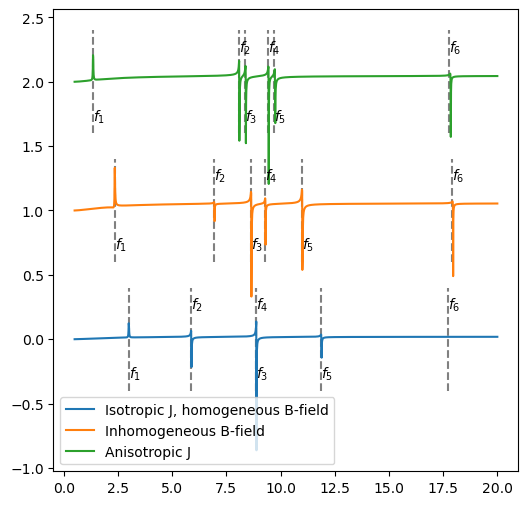

In [13]:
fig, ax = plt.subplots(1,1, figsize=(6,6))
ax = [ax]

ax[0].vlines(resonant  , -.4+0*shift, .4+0*shift, 'gray', '--')
ax[0].vlines(resonant_two_field, -.4+1*shift, .4+1*shift, 'gray', '--')
ax[0].vlines(resonant_anisop, -.4+2*shift, .4+2*shift, 'gray', '--')

ax[0].plot(frequencies, I1n+0*shift, label='Isotropic J, homogeneous B-field')
ax[0].plot(frequencies, I1_two_field_n+1*shift, label='Inhomogeneous B-field')
ax[0].plot(frequencies, I1_anisop_n+2*shift, label='Anisotropic J')

ax[0].text(resonant[0],0*shift-.2,r'$f_1$', ha='left', va='top')
ax[0].text(resonant[1],0*shift+.2,r'$f_2$', ha='left', va='bottom')
ax[0].text(resonant[2],0*shift-.2,r'$f_3$', ha='left', va='top')
ax[0].text(resonant[3],0*shift+.2,r'$f_4$', ha='left', va='bottom')
ax[0].text(resonant[4],0*shift-.2,r'$f_5$', ha='left', va='top')
ax[0].text(resonant[5],0*shift+.2,r'$f_6$', ha='left', va='bottom')

ax[0].text(resonant_two_field[0],1*shift-.2,r'$f_1$', ha='left', va='top')
ax[0].text(resonant_two_field[1],1*shift+.2,r'$f_2$', ha='left', va='bottom')
ax[0].text(resonant_two_field[2],1*shift-.2,r'$f_3$', ha='left', va='top')
ax[0].text(resonant_two_field[3],1*shift+.2,r'$f_4$', ha='left', va='bottom')
ax[0].text(resonant_two_field[4],1*shift-.2,r'$f_5$', ha='left', va='top')
ax[0].text(resonant_two_field[5],1*shift+.2,r'$f_6$', ha='left', va='bottom')

ax[0].text(resonant_anisop[0],2*shift-.2,r'$f_1$', ha='left', va='top')
ax[0].text(resonant_anisop[1],2*shift+.2,r'$f_2$', ha='left', va='bottom')
ax[0].text(resonant_anisop[2],2*shift-.2,r'$f_3$', ha='left', va='top')
ax[0].text(resonant_anisop[3],2*shift+.2,r'$f_4$', ha='left', va='bottom')
ax[0].text(resonant_anisop[4],2*shift-.2,r'$f_5$', ha='left', va='top')
ax[0].text(resonant_anisop[5],2*shift+.2,r'$f_6$', ha='left', va='bottom')

plt.legend()
plt.show()